# **Improving Customer Retention through Payment Analytics**


This notebook links payment behavior, delivery outcomes, and satisfaction signals to identify practical retention actions.

In the **Olist** ecosystem, some customers pay in a single installment, while others use up to 24. The goal is to **analyze if payment installments and payment type (Credit Card vs. Voucher/Boleto) affect Customer Satisfaction (Review Scores) and Delivery Speed**.

## Imports


Imports are centralized here so later sections focus on business logic and analysis, not setup.

In [141]:
import sys
from pathlib import Path

import dash
import kagglehub
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dash import Input, Output, callback, dcc, html
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import (
    build_clean_dataset,
    build_feature_engineered_dataset,
    build_master_dataset,
    get_numeric_feature_set,
    load_raw_tables,
    plot_shap_summary,
    prepare_intervention_payload,
    run_full_ml_workflow,
    save_model_artifacts,
    summarize_join_quality,
    summarize_table_shapes,
)

## **Download DataSet**

A single download step keeps all joins and derived features tied to one consistent raw snapshot.

In [142]:
# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

DATA_DIR = Path(path)
print("Dataset downloaded to:", DATA_DIR)
print("\nFiles available:")
for f in sorted(DATA_DIR.glob("*.csv")):
    print(f"  {f.name}")

Dataset downloaded to: C:\Users\laura\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2

Files available:
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


## **Data Strategy**

We build one reliable order-level table before modeling so every metric is comparable and traceable.

In [143]:
# Load all source tables using reusable src utilities
tables = load_raw_tables(DATA_DIR)
orders = tables["orders"]
payments = tables["payments"]
reviews = tables["reviews"]
customers = tables["customers"]
items = tables["items"]
products = tables["products"]
category_translation = tables["category_translation"]

print("\nTable shapes:")
display(summarize_table_shapes(tables))


Table shapes:


,table,rows,columns
0,orders,99441,8
1,payments,103886,5
2,reviews,99224,7
3,customers,99441,5
4,items,112650,7
5,products,32951,9
6,category_translation,71,2


### Handling Missing Values

Early missing-data checks separate expected operational gaps from quality issues that could bias results.

In [144]:
# Orders with missing delivery date are the ones not yet delivered — expected
print(f"\nOrders total:               {len(orders):,}")
print(f"Delivered orders:           {orders['order_delivered_customer_date'].notna().sum():,}")
print(f"Unique customers:           {orders['customer_id'].nunique():,}")
 
# Payments: some orders have multiple payment rows (split payments)
print(f"\nPayment rows:               {len(payments):,}")
print(f"Unique orders in payments:  {payments['order_id'].nunique():,}")
print(f"Payment types:\n{payments['payment_type'].value_counts()}")


Orders total:               99,441
Delivered orders:           96,476
Unique customers:           99,441

Payment rows:               103,886
Unique orders in payments:  99,440
Payment types:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


### Aggregate payments per order

Payment rows are collapsed to one order-level record so each order has a stable payment representation.

- An order can be paid in multiple ways (e.g. voucher + credit card).
- Strategy: keep the dominant payment type (highest value), sum installments and total payment value across all payment rows for that order.

In [145]:
master_payload = build_master_dataset(tables=tables, delivered_only=True)
payments_agg = master_payload["payments_agg"]
items_agg = master_payload["items_agg"]
reviews_clean = master_payload["reviews_clean"]
orders_delivered = master_payload["orders"]
df = master_payload["data"]

print(f"\nAggregated payment rows: {len(payments_agg):,}")
print(f"Split-payment orders:    {(payments_agg['n_payment_methods'] > 1).sum():,}")


Aggregated payment rows: 99,440
Split-payment orders:    2,246


### Aggregate items per order

Item-level detail is consolidated to preserve order value and category context at the modeling grain.

In [146]:
print(f"\nAggregated item rows: {len(items_agg):,}")
display(items_agg.head(3))


Aggregated item rows: 98,666


,order_id,total_price,total_freight,n_items,product_category,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.9,13.29,1,cool_stuff,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.9,19.93,1,pet_shop,259.83
2,000229ec398224ef6ca0657da4fc703e,199.0,17.87,1,furniture_decor,216.87


### Keep one review per order (most recent if duplicates exist)

Deduplicating reviews prevents target duplication and keeps one satisfaction label per order.

In [147]:
print(f"\nReview rows (deduplicated): {len(reviews_clean):,}")
display(reviews_clean.head(3))


Review rows (deduplicated): 98,673


,order_id,review_score,review_creation_date,review_comment_message
10764,bd2c2c3a4d59e68fb14a526745572883,4,2018-08-31,NaN
55456,529a65336debb1c3e3327d7d67dc733d,5,2018-08-31,NaN
96338,b0e9288a209f5ec50391c140dba4c91f,5,2018-08-31,NaN


### Keep only delivered orders

Delivery-time features are only valid for completed deliveries, so filtering improves feature meaning.

In [148]:
print(f"\nDelivered orders: {len(orders_delivered):,}")


Delivered orders: 96,478


### Master join

The master join unifies payment, logistics, customer, and review signals into one analytical base table.

In [149]:
print(f"\nMaster dataframe shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Master dataframe shape: (96478, 24)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_type', 'payment_installments', 'total_payment_value', 'n_payment_methods', 'review_score', 'review_creation_date', 'review_comment_message', 'total_price', 'total_freight', 'n_items', 'product_category', 'total_order_value']


### Check join quality

Null-rate diagnostics confirm whether merge logic preserved enough usable data for downstream modeling.

In [150]:
join_quality = summarize_join_quality(df)

print("\nColumns with nulls after join:")
print(join_quality.to_string(index=False))


Columns with nulls after join:
                       column  null_count  null_pct
       review_comment_message       57576     59.68
             product_category        1351      1.40
                 review_score         646      0.67
         review_creation_date         646      0.67
            order_approved_at          14      0.01
order_delivered_customer_date           8      0.01
 order_delivered_carrier_date           2      0.00
            n_payment_methods           1      0.00
          total_payment_value           1      0.00
         payment_installments           1      0.00
                 payment_type           1      0.00


## **Feature Engineering**

Transformations here convert raw transactions into operational and behavioral predictors for retention modeling.

### Delivery features

Delivery speed and lateness strongly influence post-purchase sentiment and churn risk.

In [151]:
df_features = build_feature_engineered_dataset(df, add_dummies=True, add_target=True)

print("Delivery features:")
print(f"  Avg delivery delta (days): {df_features['delivery_delta'].mean():.1f}")
print(
    f"  Late orders: {df_features['is_late'].sum():,} "
    f"({df_features['is_late'].mean() * 100:.1f}%)"
)

Delivery features:
  Avg delivery delta (days): 10.9
  Late orders: 7,661 (8.0%)


### Customer lifetime orders

Repeat-order count acts as a simple loyalty signal and helps distinguish transactional vs. recurring buyers.

In [152]:
print(
    f"\nRepeat buyers (>1 order): "
    f"{(df_features['customer_lifetime_orders'] > 1).sum():,}"
)


Repeat buyers (>1 order): 5,869


### One-hot encode payment type

Categorical encoding lets models estimate non-linear effects across payment methods without ordinal bias.

In [153]:
print(
    f"\nPayment dummy columns: "
    f"{[c for c in df_features.columns if c.startswith('payment_')]}"
)


Payment dummy columns: ['payment_type', 'payment_installments', 'payment_boleto', 'payment_credit_card', 'payment_debit_card', 'payment_voucher', 'payment_label']


### Binary satisfaction target

Binary labeling reframes review outcomes into a retention-focused objective: satisfied vs. at-risk.

In [154]:
print("\nSatisfaction split:")
print(df_features["high_satisfaction"].value_counts(normalize=True).round(3))


Satisfaction split:
high_satisfaction
1    0.789
0    0.211
Name: proportion, dtype: float64


### Final clean dataset

Final filtering removes rows missing core predictors to keep model training numerically stable.

In [155]:
clean_payload = build_clean_dataset(df_features)
ML_FEATURES = clean_payload["ml_features"]
df_clean = clean_payload["data"]

print(f"\nFinal clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Dropped {clean_payload['dropped_rows']:,} rows with missing ML features")

df_clean[[
    "order_id",
    "customer_state",
    "payment_type",
    "payment_installments",
    "total_order_value",
    "delivery_delta",
    "is_late",
    "review_score",
    "high_satisfaction",
]].head(5)


Final clean dataset: 95,823 rows × 37 columns
Dropped 9 rows with missing ML features


,order_id,customer_state,payment_type,payment_installments,total_order_value,delivery_delta,is_late,review_score,high_satisfaction
0,e481f51cbdc54678b7cc49136f2d6af7,SP,voucher,3.0,38.71,7.0,0,4.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,BA,boleto,1.0,141.46,5.0,0,4.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,GO,credit_card,3.0,179.12,17.0,0,5.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,credit_card,1.0,72.20,12.0,0,5.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,credit_card,1.0,28.62,9.0,0,5.0,1


## **EDA**

This section validates hypotheses visually, saves reproducible figure artifacts, and supports interactive exploration via Dash.

- From project root: `python dashboard.py`
- From notebooks folder: `python ..\dashboard.py`
- Then open http://localhost:8050 in your browser

In [156]:
# ── Launch the EDA Dashboard ─────────────────────────────────────────────────
# Starts dashboard.py as a background process so the notebook stays interactive.
# After running this cell, open: http://127.0.0.1:8050/
# To stop the server, run:  _dashboard_proc.terminate()

import subprocess, sys, time
from pathlib import Path

_dash_root = project_root  # already set at the top of the notebook

_dashboard_proc = subprocess.Popen(
    [sys.executable, str(_dash_root / "dashboard.py")],
    cwd=str(_dash_root),
)

# Give the server a moment to start
time.sleep(3)
print(f"Dashboard running at http://127.0.0.1:8050/  (PID {_dashboard_proc.pid})")
print("   To stop: run  _dashboard_proc.terminate()")


Dashboard running at http://127.0.0.1:8050/  (PID 30152)
   To stop: run  _dashboard_proc.terminate()


In [157]:
# Build and persist key EDA figures
FIGURES_DIR = project_root / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BRAZIL_GEOJSON = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
COLOR_MAP = {
    "Credit card": "#185FA5",
    "Boleto": "#D85A30",
    "Voucher": "#1D9E75",
    "Debit card": "#7F77DD",
}

eda_figures = {}

fig_installments = px.histogram(
    df_clean,
    x="payment_installments",
    title="Installment Distribution",
    color_discrete_sequence=["#185FA5"],
)
fig_installments.update_layout(template="plotly_white")
eda_figures["installment_distribution"] = fig_installments

corr_cols = [
    "payment_installments",
    "total_order_value",
    "total_freight",
    "delivery_delta",
    "delivery_speed_days",
    "is_late",
    "review_score",
    "customer_lifetime_orders",
]
corr_matrix = df_clean[corr_cols].corr().round(2)
corr_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_masked = corr_matrix.where(~corr_mask)
fig_corr = px.imshow(
    corr_masked,
    text_auto=True,
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1,
    title="Correlation Matrix (Lower Triangle)",
)
fig_corr.update_layout(template="plotly_white")
eda_figures["correlation_matrix"] = fig_corr

payment_share = df_clean.groupby(["customer_state", "payment_label"]).size().reset_index(name="orders")
payment_share["share_pct"] = (
    payment_share["orders"]
    / payment_share.groupby("customer_state")["orders"].transform("sum")
    * 100
)
fig_payment_share = px.bar(
    payment_share,
    x="customer_state",
    y="share_pct",
    color="payment_label",
    color_discrete_map=COLOR_MAP,
    title="Payment Method Share by State",
)
fig_payment_share.update_layout(template="plotly_white", barmode="stack", xaxis_tickangle=-45)
eda_figures["payment_share_by_state"] = fig_payment_share

late_state = df_clean.groupby("customer_state").agg(
    orders=("order_id", "count"),
    late_orders=("is_late", "sum"),
).reset_index()
late_state["late_rate"] = (late_state["late_orders"] / late_state["orders"]) * 100
fig_late_rate = px.choropleth(
    late_state,
    geojson=BRAZIL_GEOJSON,
    locations="customer_state",
    featureidkey="properties.sigla",
    color="late_rate",
    color_continuous_scale="Reds",
    title="Late Delivery % by State",
)
fig_late_rate.update_geos(fitbounds="locations", visible=False)
fig_late_rate.update_layout(template="plotly_white")
eda_figures["late_delivery_rate_map"] = fig_late_rate

saved_eda_paths = {}
for figure_name, figure in eda_figures.items():
    figure_path = FIGURES_DIR / f"{figure_name}.html"
    figure.write_html(str(figure_path))
    saved_eda_paths[figure_name] = str(figure_path)

print("Saved EDA figures:")
display(pd.DataFrame({"figure": saved_eda_paths.keys(), "path": saved_eda_paths.values()}))

fig_installments.show()
fig_corr.show()
fig_payment_share.show()
fig_late_rate.show()

Saved EDA figures:


,figure,path
0,installment_distribution,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
1,correlation_matrix,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
2,payment_share_by_state,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
3,late_delivery_rate_map,c:\Users\laura\OneDrive\Documents\Estudios\DAT...


In [158]:
# ── Correlation with review_score ─────────────────────────────────────────────
# Pearson correlation for every numeric feature against the raw review_score.
# Blue bars = positive correlation (higher value → better satisfaction).
# Red bars  = negative correlation (higher value → worse satisfaction).

import plotly.graph_objects as go

_candidate_cols = [
    "payment_installments", "total_order_value", "total_price",
    "total_freight", "delivery_delta", "delivery_speed_days",
    "is_late", "customer_lifetime_orders", "review_sentiment",
]
_numeric_cols = [c for c in _candidate_cols if c in df_clean.columns]

corr_series = (
    df_clean[_numeric_cols + ["review_score"]]
    .corr()["review_score"]
    .drop("review_score")
    .sort_values()
)

_bar_colors = ["#E05252" if v < 0 else "#185FA5" for v in corr_series.values]

fig_corr_score = go.Figure(
    go.Bar(
        x=corr_series.values,
        y=corr_series.index,
        orientation="h",
        marker_color=_bar_colors,
        text=[f"{v:+.3f}" for v in corr_series.values],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_corr_score.update_layout(
    title="Pearson Correlation with review_score",
    xaxis_title="Correlation coefficient",
    plot_bgcolor="#FFFFFF",
    paper_bgcolor="#F0F2F6",
    height=420,
    margin=dict(l=12, r=70, t=50, b=12),
    font=dict(family="'Inter','Segoe UI',sans-serif", size=12),
    xaxis=dict(
        zeroline=True, zerolinewidth=1.5, zerolinecolor="#AAAAAA",
        range=[corr_series.min() - 0.15, corr_series.max() + 0.15],
    ),
)
fig_corr_score.show()
eda_figures["correlation_review_score"] = fig_corr_score

# Persist as PNG for the dashboard / reports
try:
    fig_corr_score.write_image(str(FIGURES_DIR / "correlation_review_score.png"))
    print("Saved → outputs/figures/correlation_review_score.png")
except Exception as _e:
    print(f"Could not save PNG (kaleido not installed?): {_e}")

# Print the raw numbers too
print("\nCorrelation values:")
print(corr_series.to_string())


Could not save PNG (kaleido not installed?): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


Correlation values:
is_late                    -0.364879
delivery_speed_days        -0.333832
total_freight              -0.089622
total_order_value          -0.041766
total_price                -0.034434
payment_installments       -0.031250
customer_lifetime_orders    0.017446
delivery_delta              0.267213
review_sentiment                 NaN


## **Machine Learning**

The ML workflow estimates low-satisfaction risk and supports intervention prioritization.

### Feature Engineering & Target Setting

This checkpoint confirms engineered predictors and target labels are ready for model training.

In [159]:
# Re-import key ML helpers in case src changed during notebook iteration
from src import get_numeric_feature_set, plot_shap_summary, run_full_ml_workflow, save_model_artifacts

if not isinstance(df_clean, pd.DataFrame):
    raise ValueError("df_clean is not ready. Run the data preparation cells first.")

### src-Powered ML Workflow (Training, Metrics, and ROC)

Reusable src functions make experiments easier to compare, reproduce, and maintain.

In [160]:
numeric_features = get_numeric_feature_set(feature_scope="post_delivery")

ml_results = run_full_ml_workflow(
    df=df_clean,
    numeric_features=numeric_features,
    feature_scope="post_delivery",
    n_clusters=4,
    compute_shap=True,
    random_state=42,
)

MODEL_DIR = project_root / "outputs" / "model"
saved_model_artifacts = save_model_artifacts(ml_results, output_dir=MODEL_DIR)

print("--- Model Metrics (sorted by low-satisfaction performance) ---")
display(ml_results["metrics"])

print("\n--- Top At-Risk Orders/Customers ---")
display(
    ml_results["risk_table"][
        [
            "scoring_model",
            "predicted_risk_band",
            "predicted_low_probability",
            "predicted_high_probability",
            "decision_threshold",
        ]
    ].head(10)
)

print("\nSaved model artifacts:")
display(
    pd.DataFrame(
        {
            "artifact": list(saved_model_artifacts.keys()),
            "path": list(saved_model_artifacts.values()),
        }
    )
)

if ml_results["roc_figure"] is not None:
    ml_results["roc_figure"].show()

--- Model Metrics (sorted by low-satisfaction performance) ---


,model,decision_threshold,validation_f1_low_satisfaction,validation_recall_low_satisfaction,f1_high_satisfaction,f1_low_satisfaction,f1_macro,precision_low_satisfaction,recall_low_satisfaction,roc_auc
0,XGBoost,0.49,0.456276,0.493498,0.833136,0.431282,0.632209,0.402533,0.464454,0.692238
1,Random Forest,0.56,0.863393,0.947059,0.853669,0.421202,0.637436,0.440508,0.403517,0.680422
2,Logistic Regression,0.52,0.417117,0.490402,0.808791,0.418266,0.613529,0.364187,0.491206,0.679358



--- Top At-Risk Orders/Customers ---


,scoring_model,predicted_risk_band,predicted_low_probability,predicted_high_probability,decision_threshold
0,XGBoost,high,0.982574,0.017426,0.49
1,XGBoost,high,0.982473,0.017527,0.49
2,XGBoost,high,0.982414,0.017586,0.49
3,XGBoost,high,0.982228,0.017772,0.49
4,XGBoost,high,0.981985,0.018015,0.49
5,XGBoost,high,0.981598,0.018402,0.49
6,XGBoost,high,0.981517,0.018483,0.49
7,XGBoost,high,0.981470,0.018530,0.49
8,XGBoost,high,0.981346,0.018654,0.49
9,XGBoost,high,0.981305,0.018695,0.49



Saved model artifacts:


,artifact,path
0,metrics,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
1,risk_table,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
2,segment_profile,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
3,predictions,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
4,model_logistic_regression,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
5,model_random_forest,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
6,model_xgboost,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
7,roc_figure,c:\Users\laura\OneDrive\Documents\Estudios\DAT...
8,segment_figure,c:\Users\laura\OneDrive\Documents\Estudios\DAT...


### Model Explainability with SHAP (via src)

Explainability clarifies which variables move risk predictions, improving trust and actionability.

Generating SHAP Summary Plot...


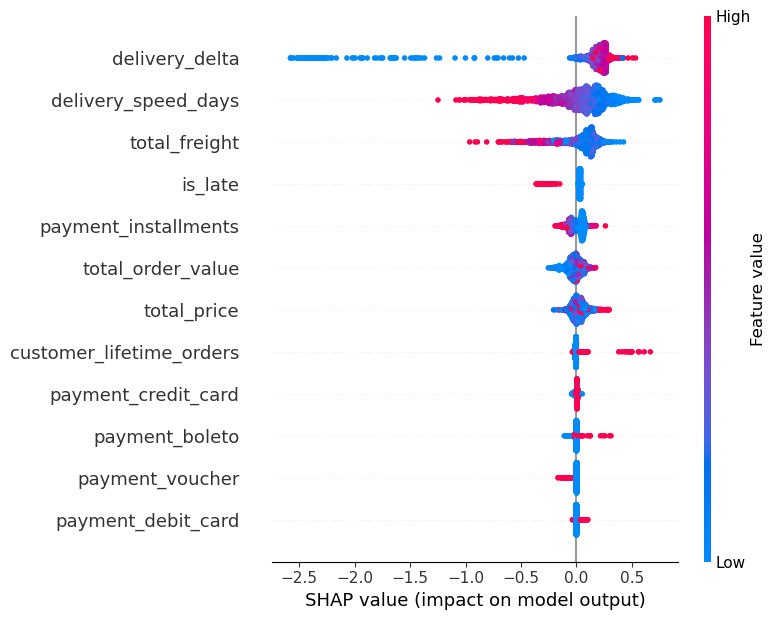

In [161]:
print("Generating SHAP Summary Plot...")

if ml_results.get("shap") is None:
    print("SHAP artifacts were not computed. Set compute_shap=True in the workflow cell.")
else:
    _ = plot_shap_summary(ml_results["shap"], max_display=12, plot_type="dot")

### Customer Segmentation and Risk Bands (via src)

Context and reasoning: Segments and risk bands translate model output into operational groups for differentiated retention plays.

In [162]:
print("--- Segment Profile ---")
display(ml_results["segment_profile"])

if ml_results["segment_figure"] is not None:
    ml_results["segment_figure"].show()

print("\n--- Risk Distribution by Band ---")
risk_distribution = (
    ml_results["risk_table"]["predicted_risk_band"]
    .value_counts(dropna=False)
    .rename_axis("predicted_risk_band")
    .reset_index(name="count")
)
display(risk_distribution)

--- Segment Profile ---


,segment,orders,payment_installments,total_order_value,delivery_delta,delivery_speed_days,is_late,customer_lifetime_orders,high_satisfaction,average_review_score,segment_label
0,3,67864,1.902555,114.384690,12.448603,10.213471,0.000000,1.000000,0.832577,4.307895,budget
1,2,14976,7.739116,370.038553,13.699119,11.335136,0.001402,1.008480,0.805222,4.218216,high-value | installment-heavy | reliably deli...
2,1,7604,3.020121,167.210914,-9.793004,30.989742,0.999737,1.049316,0.344424,2.560231,late-delivery risk | satisfaction risk
3,0,5379,3.191857,132.749433,13.063209,10.469418,0.006879,2.253765,0.828593,4.320134,budget | reliably delivered | repeat buyers



--- Risk Distribution by Band ---


,predicted_risk_band,count
0,medium,49374
1,low,40150
2,high,6299


In [163]:
print("--- Business Recommendations ---")

risk_counts = ml_results["risk_table"]["predicted_risk_band"].value_counts()
top_band = risk_counts.index[0]
top_band_count = int(risk_counts.iloc[0])
total_orders = int(risk_counts.sum())
top_band_pct = (top_band_count / total_orders) * 100

segment_profile = ml_results["segment_profile"].copy()
segment_profile["low_satisfaction_rate"] = 1 - segment_profile["high_satisfaction"]
priority_segment = segment_profile.sort_values(
    ["low_satisfaction_rate", "orders"],
    ascending=[False, False],
).iloc[0]

print(
    f"1) Primary risk concentration: '{top_band}' band with {top_band_count:,} orders "
    f"({top_band_pct:.1f}% of scored population)."
)
print(
    "2) Priority segment for retention actions: "
    f"segment {int(priority_segment['segment'])} ({priority_segment['segment_label']}) "
    f"with low-satisfaction rate of {priority_segment['low_satisfaction_rate']*100:.1f}% "
    f"across {int(priority_segment['orders']):,} orders."
)
print(
    "3) Suggested playbook: apply strongest incentives and proactive service outreach to high-risk "
    "orders in the priority segment; use lighter nudges for medium-risk orders."
)

--- Business Recommendations ---
1) Primary risk concentration: 'medium' band with 49,374 orders (51.5% of scored population).
2) Priority segment for retention actions: segment 1 (late-delivery risk | satisfaction risk) with low-satisfaction rate of 65.6% across 7,604 orders.
3) Suggested playbook: apply strongest incentives and proactive service outreach to high-risk orders in the priority segment; use lighter nudges for medium-risk orders.


### Operational Validation: Cost, Geography, and Targeted Intervention

Validation links model errors to financial impact and identifies where interventions matter most.

In [164]:
# -----------------------------------------------------------------------------
# 1) Cost-Benefit: Cost of False Negatives (actual low satisfaction predicted as high)
# -----------------------------------------------------------------------------
risk_table = ml_results["risk_table"].copy()
clustered_data = ml_results["segmentation"]["clustered_data"].copy()
segment_profile = ml_results["segment_profile"].copy()

join_key = "order_id" if "order_id" in risk_table.columns and "order_id" in clustered_data.columns else None
if join_key is None:
    raise ValueError("Could not find a common key (order_id) to join risk and segment outputs.")

# clustered_data stores segment id; labels are in segment_profile
segment_lookup = clustered_data[[join_key, "segment"]].drop_duplicates(subset=[join_key])
segment_labels = segment_profile[["segment", "segment_label"]].drop_duplicates(subset=["segment"])
segment_lookup = segment_lookup.merge(segment_labels, on="segment", how="left")
risk_enriched = risk_table.merge(segment_lookup, on=join_key, how="left")

false_negative_mask = (
    (risk_enriched["high_satisfaction"] == 0)
    & (risk_enriched["predicted_high_satisfaction"] == 1)
)
false_negative_orders = risk_enriched[false_negative_mask].copy()

fn_cost_by_segment = (
    false_negative_orders.groupby(["segment", "segment_label"], dropna=False)
    .agg(
        false_negative_orders=(join_key, "count"),
        estimated_lost_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean"),
    )
    .sort_values("estimated_lost_revenue", ascending=False)
    .reset_index()
)

print("--- Cost of False Negatives by Segment ---")
display(fn_cost_by_segment.head(5))

# -----------------------------------------------------------------------------
# 2) State-Level Sentiment: Is the late-delivery-risk segment geographically concentrated?
# -----------------------------------------------------------------------------
late_risk_match = segment_profile["segment_label"].str.contains("late-delivery risk", case=False, na=False)
if late_risk_match.any():
    late_segment_id = int(segment_profile.loc[late_risk_match, "segment"].iloc[0])
else:
    # Fallback: segment with highest observed late rate
    late_segment_id = int(segment_profile.sort_values("is_late", ascending=False).iloc[0]["segment"])

clustered_geo = clustered_data.copy()
clustered_geo["is_late_segment"] = (clustered_geo["segment"] == late_segment_id).astype(int)
overall_late_segment_share = clustered_geo["is_late_segment"].mean()

state_late_summary = (
    clustered_geo.groupby("customer_state", dropna=False)
    .agg(
        orders=(join_key, "count"),
        late_segment_orders=("is_late_segment", "sum"),
    )
    .reset_index()
)
state_late_summary["late_segment_share"] = state_late_summary["late_segment_orders"] / state_late_summary["orders"]
state_late_summary["late_segment_lift_vs_overall"] = (
    state_late_summary["late_segment_share"] / overall_late_segment_share
)
state_late_summary = state_late_summary.sort_values(
    ["late_segment_lift_vs_overall", "late_segment_orders"],
    ascending=[False, False],
)

print(f"\n--- State Concentration for Late-Delivery Segment (segment={late_segment_id}) ---")
print(f"Overall share of this segment: {overall_late_segment_share*100:.2f}%")
display(state_late_summary.head(5))

# -----------------------------------------------------------------------------
# 3) Proactive Intervention: delayed-shipping email only for High Risk band
# -----------------------------------------------------------------------------
intervention_candidates = risk_enriched[
    (risk_enriched["predicted_risk_band"] == "high")
    & (
        ((risk_enriched["is_late"] == 1) if "is_late" in risk_enriched.columns else False)
        | ((risk_enriched["delivery_delta"] < 0) if "delivery_delta" in risk_enriched.columns else False)
    )
].copy()

population_size = len(risk_enriched)
candidate_size = len(intervention_candidates)
candidate_pct = (candidate_size / population_size * 100) if population_size else 0.0

print("\n--- Delayed-Shipping High-Risk Intervention Pool ---")
print(
    f"Candidates: {candidate_size:,} / {population_size:,} orders "
    f"({candidate_pct:.2f}% of scored orders)"
)

preview_columns = [
    col for col in [
        "order_id",
        "customer_unique_id",
        "customer_state",
        "payment_type",
        "total_order_value",
        "delivery_delta",
        "predicted_low_probability",
        "predicted_risk_band",
        "segment",
        "segment_label",
    ]
    if col in intervention_candidates.columns
]

display(
    intervention_candidates[preview_columns]
    .sort_values("predicted_low_probability", ascending=False)
    .head(5)
)

# Compact message payload table for downstream email automation
intervention_payload = intervention_candidates[[
    col for col in [
        "order_id",
        "customer_unique_id",
        "customer_state",
        "payment_type",
        "total_order_value",
        "delivery_delta",
        "predicted_low_probability",
    ]
    if col in intervention_candidates.columns
]].copy()

if "delivery_delta" in intervention_payload.columns:
    intervention_payload["delay_days"] = intervention_payload["delivery_delta"].abs().round(0).astype(int)

if "predicted_low_probability" in intervention_payload.columns:
    intervention_payload["risk_pct"] = (intervention_payload["predicted_low_probability"] * 100).round(1)

print("\nPrepared intervention_payload for export/automation.")

--- Cost of False Negatives by Segment ---


,segment,segment_label,false_negative_orders,estimated_lost_revenue,avg_order_value
0,3,budget,8368,890624.17,106.432143
1,2,high-value | installment-heavy | reliably deli...,1581,555745.10,351.514927
2,0,budget | reliably delivered | repeat buyers,638,79461.27,124.547445
3,1,late-delivery risk | satisfaction risk,56,5941.06,106.090357



--- State Concentration for Late-Delivery Segment (segment=1) ---
Overall share of this segment: 7.94%


,customer_state,orders,late_segment_orders,late_segment_share,late_segment_lift_vs_overall
1,AL,394,92,0.233503,2.942519
9,MA,712,134,0.188202,2.371660
16,PI,471,75,0.159236,2.006633
5,CE,1273,195,0.153181,1.930340
24,SE,334,50,0.149701,1.886476



--- Delayed-Shipping High-Risk Intervention Pool ---
Candidates: 5,935 / 95,823 orders (6.19% of scored orders)


,order_id,customer_unique_id,customer_state,payment_type,total_order_value,delivery_delta,predicted_low_probability,predicted_risk_band,segment,segment_label
0,03ea231452f07988edc699573fb971d7,6f40da67e9ca1ffe08bbbc2fb761e75a,SP,credit_card,255.96,-29.0,0.982574,high,1,late-delivery risk | satisfaction risk
1,70be4f36c3ba5f5c95734da20d4c34a7,48c1b34a2d23e13b8967caa478d9c428,CE,credit_card,230.04,-13.0,0.982473,high,1,late-delivery risk | satisfaction risk
2,0c1131dcb8c6ec0c895af6aea3e70983,91d5da8c24686b483a7b08bfddf5c344,CE,credit_card,218.10,-12.0,0.982414,high,1,late-delivery risk | satisfaction risk
3,c91097d5f017e8117c4930db4bc51c66,fd5233d2c8437ce53379939fa12ad908,BA,credit_card,217.92,-15.0,0.982228,high,1,late-delivery risk | satisfaction risk
4,43f312594026fc6c67ccf619afe600d1,607eabaa3707bbcbb4313d9d3c81d385,SC,voucher,241.22,-21.0,0.981985,high,1,late-delivery risk | satisfaction risk



Prepared intervention_payload for export/automation.


### VIP-Weighted Retraining (Sample Weight for High-Value Segment)

Weighted training evaluates whether prioritizing high-value customers improves business-critical outcomes.

In [165]:
import importlib
import src.model as model_utils

model_utils = importlib.reload(model_utils)

weighted_artifacts = model_utils.train_vip_weighted_xgboost(
    training=ml_results["training"],
    risk_enriched=risk_enriched,
    segment_profile=segment_profile,
    vip_weight=2.0,
    low_satisfaction_weight=1.0,
    random_state=42,
)

print(f"VIP segment used for weighting: {weighted_artifacts['vip_segment_id']}")
display(weighted_artifacts["summary"])
print(
    "VIP false-negative revenue (lower is better) | "
    f"baseline: {weighted_artifacts['fn_revenue_baseline']:,.2f} "
    f"vs weighted: {weighted_artifacts['fn_revenue_weighted']:,.2f}"
)

VIP segment used for weighting: 2


,model_variant,decision_threshold,f1_low_satisfaction,recall_low_satisfaction,precision_low_satisfaction,roc_auc
0,Baseline XGBoost,0.49,0.431282,0.464454,0.402533,0.692238
1,VIP-weighted XGBoost,0.69,0.432154,0.518702,0.370357,0.692305


VIP false-negative revenue (lower is better) | baseline: 124,496.25 vs weighted: 116,525.64


### Revenue at Risk Map: High-Value Segment with Late Deliveries

Mapping at-risk revenue by state helps localize fulfillment interventions for maximum return.

In [166]:
import importlib
import src.model as model_utils

model_utils = importlib.reload(model_utils)

# Focus on the most expensive segment and only late deliveries
vip_segment_id = weighted_artifacts["vip_segment_id"] if "weighted_artifacts" in globals() else int(segment_profile.sort_values("total_order_value", ascending=False).iloc[0]["segment"])

rev_risk_state = model_utils.build_revenue_at_risk_table(
    risk_enriched=risk_enriched,
    vip_segment_id=vip_segment_id,
)

print("--- Revenue at Risk by State (VIP + Late) ---")
display(rev_risk_state.head(5))

geojson_url = BRAZIL_GEOJSON if "BRAZIL_GEOJSON" in globals() else "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
fig_rev_risk = model_utils.build_revenue_at_risk_map(
    revenue_at_risk_table=rev_risk_state,
    geojson_url=geojson_url,
)
fig_rev_risk.show()

--- Revenue at Risk by State (VIP + Late) ---


,customer_state,vip_late_orders,revenue_at_risk,avg_order_value
0,SP,11,19857.53,1805.230000
1,RJ,6,7910.08,1318.346667
2,MA,1,2338.48,2338.480000
3,GO,1,2115.79,2115.790000
4,PR,1,1843.85,1843.850000


### Export Intervention Payload for Email Agent (with Personalization Metadata)

The final payload packages predictions and personalization fields so campaigns can be operationalized immediately.

In [167]:
from pathlib import Path
import importlib
import src.model as model_utils

model_utils = importlib.reload(model_utils)

export_path = Path("outputs") / "intervention" / "intervention_payload_high_risk_late.csv"
export_result = model_utils.prepare_intervention_payload(
    intervention_candidates=intervention_candidates,
    output_path=export_path,
)

agent_payload = export_result["payload"]

print(f"Exported: {export_result['exported_to']}")
print(f"Rows: {len(agent_payload):,}")
display(agent_payload.head(5))

Exported: outputs\intervention\intervention_payload_high_risk_late.csv
Rows: 5,935


,order_id,customer_unique_id,customer_state,payment_type,payment_installments,product_category,total_order_value,total_price,total_freight,delivery_delta,...,predicted_high_probability,predicted_risk_band,segment,segment_label,delay_days,risk_pct,value_tier,recommended_coupon_pct,campaign_reason,apology_style
0,03ea231452f07988edc699573fb971d7,6f40da67e9ca1ffe08bbbc2fb761e75a,SP,credit_card,1.0,furniture_living_room,255.96,207.94,48.02,-29.0,...,0.017426,high,1,late-delivery risk | satisfaction risk,29,98.300003,high,25,late_delivery_high_risk,white_glove
1,70be4f36c3ba5f5c95734da20d4c34a7,48c1b34a2d23e13b8967caa478d9c428,CE,credit_card,2.0,bed_bath_table,230.04,179.80,50.24,-13.0,...,0.017527,high,1,late-delivery risk | satisfaction risk,13,98.199997,high,25,late_delivery_high_risk,white_glove
2,0c1131dcb8c6ec0c895af6aea3e70983,91d5da8c24686b483a7b08bfddf5c344,CE,credit_card,4.0,office_furniture,218.10,169.99,48.11,-12.0,...,0.017586,high,1,late-delivery risk | satisfaction risk,12,98.199997,high,25,late_delivery_high_risk,white_glove
3,c91097d5f017e8117c4930db4bc51c66,fd5233d2c8437ce53379939fa12ad908,BA,credit_card,4.0,baby,217.92,169.90,48.02,-15.0,...,0.017772,high,1,late-delivery risk | satisfaction risk,15,98.199997,high,25,late_delivery_high_risk,white_glove
4,43f312594026fc6c67ccf619afe600d1,607eabaa3707bbcbb4313d9d3c81d385,SC,voucher,1.0,watches_gifts,241.22,224.90,16.32,-21.0,...,0.018015,high,1,late-delivery risk | satisfaction risk,21,98.199997,high,25,late_delivery_high_risk,white_glove
